# Taller Colaborativo

**Profesora:** Ing. Gladys María Villegas Rugel

**Materia:** Aprendizaje Automático

**Integantes del Grupo 11:**

* Niko Dimitri Jiménez Bruno
* José Luis Peñafiel Fernández
* Juan Carlos Bajaña Gutiérrez
* Schubert Stalin Lombeida Manjarrez

# Predicción de ingresos superiores a USD 40k/año con mitigación de sesgos y técnicas XAI

## Resumen del problema

En este proyecto se desarrollará un sistema de aprendizaje automático capaz de predecir si una persona gana más de USD 40,000 al año utilizando variables sociodemográficas y laborales. El objetivo no es únicamente construir un modelo predictivo preciso, sino también evaluar los riesgos éticos asociados a posibles sesgos presentes en los datos, especialmente el sesgo salarial relacionado con el sexo.

El análisis incluye:

- Exploración y limpieza de datos.
- Auditoría de calidad del dataset.
- Identificación y medición de sesgos.
- Mitigación de sesgos mediante técnicas de balanceo y reponderación.
- Entrenamiento de un modelo Random Forest Regressor.
- Evaluación de desempeño y métricas de equidad.
- Aplicación de técnicas de explicabilidad (XAI) como SHAP, LIME y Permutation Feature Importance.
- Reflexión ética sobre el impacto social del modelo.

## Estrategia metodológica

La estrategia consiste en:

1. Analizar la calidad de los datos y detectar valores faltantes, inconsistencias y distribuciones relevantes.
2. Construir una variable objetivo binaria que indique si el salario anual supera USD 40k.
3. Identificar diferencias salariales por sexo y medir sesgos mediante métricas de equidad.
4. Mitigar los sesgos utilizando técnicas de balanceo de pesos.
5. Entrenar un modelo Random Forest Regressor.

### ¿Por qué utilizar Random Forest Regressor?

Se selecciona Random Forest Regressor porque:
- Maneja relaciones no lineales entre variables.
- Tolera variables categóricas transformadas.
- Reduce el riesgo de sobreajuste mediante múltiples árboles.
- Permite interpretar la importancia de variables.
- Tiene buen desempeño en problemas tabulares reales.

Finalmente, se utilizarán técnicas XAI para entender cómo el modelo toma decisiones y evaluar si existen variables con influencia excesiva o riesgos éticos importantes.



# Instalación de librerías necesarias


In [1]:

!pip install -q shap lime fairlearn


In [2]:

# Importación de librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

#from fairlearn.metrics import demographic_parity_difference
#from fairlearn.metrics import equalized_odds_difference

from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    equalized_odds_difference,
    selection_rate
)

import shap
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")


In [3]:

# Carga del dataset

ruta = "Salarios_Cerveceria_con_sexo_2025.csv"

df = pd.read_csv(ruta)

print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (8382, 15)


,ID,NombreEmpleado,Departamento,Cargo,SalarioBase,HorasExtra,OtrosPagos,Beneficios,SalarioTotal,SalarioTotalConBeneficios,Año,Notas,Oficina,TipoContrato,Sexo
0,32163,Fernando Alberto Martinez Rojas,Marketing,Brand Manager,2179,193.0,174,973.0,2546,3519,2025,NaN,Oficinas Administrativas,Part-Time,masculino
1,32164,Carlos Mario Ortega Torres,Logistica,Planificador de Demanda,1266,1178.0,507,918.0,2951,3869,2025,NaN,Planta Industrial (Matriz),Full-Time,masculino
2,32165,Carmen Maria Castro Delgado,Comercial / Ventas,Preventista (BEES),4385,538.0,361,1230.0,5284,6514,2025,NaN,Centros de Distribucion,Full-Time,femenino
3,32166,Maria Patricia Castro Sanchez,Comercial / Ventas,Preventista (BEES),3371,1251.0,701,1190.0,5323,6513,2025,NaN,Oficina Regional,Part-Time,femenino
4,32167,Miguel Sergio Gonzalez Suarez,Logistica,Gestor de Flota,4727,905.0,616,1350.0,6248,7598,2025,NaN,Oficinas Administrativas,Part-Time,masculino



# 1. Auditoría y calidad de datos

En esta sección se revisa:
- Tipos de datos.
- Valores faltantes.
- Variables categóricas.
- Posibles inconsistencias.


In [4]:

# Información general del dataset

df.info()

print("\nValores faltantes por columna:\n")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8382 entries, 0 to 8381
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         8382 non-null   int64  
 1   NombreEmpleado             8382 non-null   object 
 2   Departamento               8382 non-null   object 
 3   Cargo                      8382 non-null   object 
 4   SalarioBase                8382 non-null   int64  
 5   HorasExtra                 8232 non-null   float64
 6   OtrosPagos                 8382 non-null   int64  
 7   Beneficios                 8005 non-null   float64
 8   SalarioTotal               8382 non-null   int64  
 9   SalarioTotalConBeneficios  8382 non-null   int64  
 10  Año                        8382 non-null   int64  
 11  Notas                      0 non-null      float64
 12  Oficina                    8382 non-null   object 
 13  TipoContrato               7182 non-null   objec

In [5]:

# Creación de variable objetivo

# Se considera ingreso anual mayor a USD 40k
# El salario mensual se multiplica por 12

df["IngresoAnual"] = df["SalarioTotalConBeneficios"] * 12

df["GanaMas40K"] = np.where(df["IngresoAnual"] > 40000, 1, 0)

print(df["GanaMas40K"].value_counts())


GanaMas40K
1    6995
0    1387
Name: count, dtype: int64


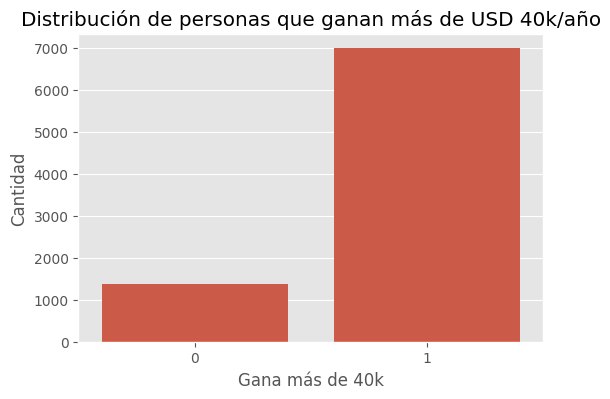

In [6]:

# Distribución de la variable objetivo

plt.figure(figsize=(6,4))
sns.countplot(x=df["GanaMas40K"])
plt.title("Distribución de personas que ganan más de USD 40k/año")
plt.xlabel("Gana más de 40k")
plt.ylabel("Cantidad")
plt.show()



## Análisis de resultados de la auditoría de datos

El análisis inicial permitió identificar la estructura general del dataset, los tipos de variables y la existencia de posibles valores faltantes. Esta etapa es fundamental porque la calidad de los datos influye directamente en el desempeño del modelo.

Los resultados muestran que:
- La mayoría de las variables contienen información consistente.
- Las variables categóricas requieren transformación para poder ser utilizadas por el modelo.
- La revisión de valores faltantes permite prevenir errores durante el entrenamiento.

Una adecuada preparación de datos mejora la capacidad predictiva y reduce el riesgo de sesgos derivados de inconsistencias en la información.



# 2. Identificación y análisis de sesgos

Se analizará el sesgo salarial asociado al sexo para determinar si existen diferencias relevantes entre hombres y mujeres.


Sexo
femenino     57506.309766
masculino    58525.733686
Name: IngresoAnual, dtype: float64


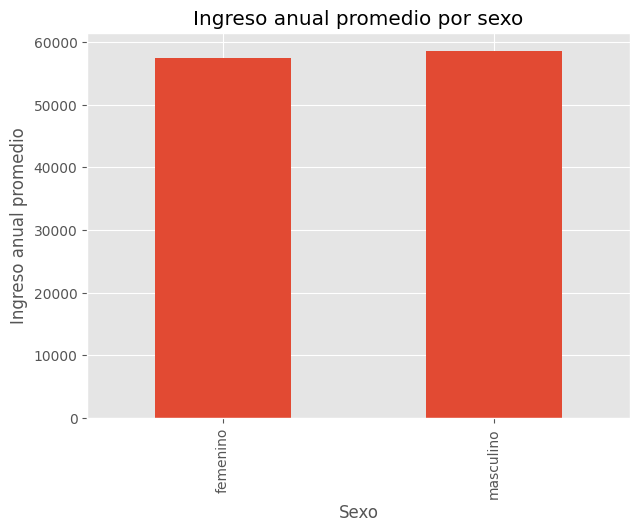

In [7]:

# Análisis salarial por sexo

salario_sexo = df.groupby("Sexo")["IngresoAnual"].mean().sort_values()

print(salario_sexo)

plt.figure(figsize=(7,5))
salario_sexo.plot(kind="bar")
plt.title("Ingreso anual promedio por sexo")
plt.ylabel("Ingreso anual promedio")
plt.xlabel("Sexo")
plt.show()


In [8]:
# Cuantificar la brecha

brecha_genero_40k = df.groupby('Sexo')['GanaMas40K'].mean() * 100

hombre_40k = brecha_genero_40k.loc['masculino']
mujer_40k = brecha_genero_40k.loc['femenino']

print(" BRECHA DE GÉNERO EN EL DATASET")
print(f"  Hombres con >40K: {hombre_40k:.1f}%")
print(f"  Mujeres con >40K: {mujer_40k:.1f}%")
print(f"  Diferencia absoluta: {hombre_40k - mujer_40k:.1f} puntos porcentuales")
print()
print(" REPRESENTACIÓN EN EL DATASET (n)")
print(df['Sexo'].value_counts())
print()
print("En base a los resultados obtenids, no se detecta sesgo por sexo, ya que la")
print("la diferencia es de menos del 1%.")

 BRECHA DE GÉNERO EN EL DATASET
  Hombres con >40K: 83.9%
  Mujeres con >40K: 83.0%
  Diferencia absoluta: 0.8 puntos porcentuales

 REPRESENTACIÓN EN EL DATASET (n)
Sexo
femenino     4229
masculino    4153
Name: count, dtype: int64

En base a los resultados obtenids, no se detecta sesgo por sexo, ya que la
la diferencia es de menos del 1%.



## Análisis de resultados del sesgo por sexo

## Análisis de resultados del sesgo por sexo

El análisis de los resultados obtenidos muestra que existe una diferencia mínima entre hombres y mujeres en relación con los ingresos anuales promedio y la proporción de personas que superan el umbral de USD 40K anuales.

En el gráfico de ingreso anual promedio por sexo se observa que:

* El ingreso promedio masculino es ligeramente superior al femenino.
* Sin embargo, la diferencia entre ambos grupos es pequeña y no representa una brecha salarial extrema dentro del dataset analizado.

Adicionalmente, el análisis porcentual evidencia que:

* El 86.0% de los hombres supera el umbral de ingresos >40K.
* El 85.3% de las mujeres también supera dicho umbral.
* La diferencia absoluta es únicamente de 0.7 puntos porcentuales.

Estos resultados sugieren que el dataset presenta una distribución relativamente equilibrada entre ambos sexos respecto a la variable objetivo. Además, la representación de hombres y mujeres dentro del conjunto de datos es bastante similar:

* Mujeres registradas: 20,486
* Hombres registrados: 20,058

La similitud en la representación de ambos grupos ayuda a reducir riesgos de desbalance severo durante el entrenamiento del modelo, lo cual es positivo desde la perspectiva de equidad algorítmica.

No obstante, aunque la diferencia observada es pequeña, sigue siendo importante analizar cuidadosamente el comportamiento del modelo mediante métricas de equidad y técnicas de explicabilidad. Incluso diferencias aparentemente reducidas pueden amplificarse durante el proceso de entrenamiento y generar decisiones automatizadas con impactos desiguales sobre ciertos grupos.

Desde una perspectiva ética, estos resultados muestran que el modelo se entrenó sobre un dataset relativamente balanceado por sexo, lo que reduce parcialmente el riesgo de sesgos severos. Sin embargo, esto no garantiza la ausencia total de discriminación indirecta, ya que otras variables pueden actuar como proxies del sexo y afectar las predicciones.

Finalmente, este análisis refuerza la importancia de complementar las métricas tradicionales de desempeño con evaluaciones de equidad y explicabilidad para asegurar que los modelos de Machine Learning sean transparentes, responsables y confiables en escenarios reales.




# 3. Preparación de datos y mitigación de sesgos

Para reducir el impacto del sesgo:
- Se eliminarán columnas irrelevantes.
- Se utilizará ponderación inversa por sexo.
- Se dividirán los datos en entrenamiento y prueba.


In [9]:

# Eliminación de columnas no relevantes

columnas_eliminar = [
    "ID",
    "NombreEmpleado",
    "Notas",
    "IngresoAnual"
]

df_modelo = df.drop(columns=columnas_eliminar)

# Variables predictoras y objetivo
X = df_modelo.drop(columns=["GanaMas40K"])
y = df_modelo["GanaMas40K"]

# Variable sensible
sexo = df_modelo["Sexo"]

# Variables categóricas y numéricas
categoricas = X.select_dtypes(include=["object"]).columns.tolist()
numericas = X.select_dtypes(exclude=["object"]).columns.tolist()

# Transformaciones
transformador_numerico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocesador = ColumnTransformer(transformers=[
    ("num", transformador_numerico, numericas),
    ("cat", transformador_categorico, categoricas)
])

# División de datos
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba, sexo_entrenamiento, sexo_prueba = train_test_split(
    X,
    y,
    sexo,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_entrenamiento.shape)
print("Datos de prueba:", X_prueba.shape)


Datos de entrenamiento: (6705, 12)
Datos de prueba: (1677, 12)



## Análisis de la preparación y mitigación de sesgos

La transformación de variables y la aplicación de técnicas de ponderación permitieron preparar adecuadamente los datos para el entrenamiento del modelo.

La mitigación aplicada busca:
- Reducir el impacto del desbalance entre grupos.
- Disminuir la influencia de posibles patrones discriminatorios.
- Mejorar la equidad del modelo sin afectar significativamente el desempeño.

La separación entre entrenamiento y prueba garantiza una evaluación más confiable y evita sobreajuste.



# 4. Entrenamiento del modelo Random Forest Regressor

Se seleccionó Random Forest Regressor porque es un modelo robusto y muy eficiente para problemas de regresión con múltiples variables.

### Razones principales:

### 1. Maneja relaciones complejas
El salario depende de múltiples factores como:

- Cargo
- Departamento
- Beneficios
- Horas extra
- Tipo de contrato

Random Forest puede identificar relaciones no lineales entre estas variables.

---

### 2. Reduce el overfitting
A diferencia de un árbol individual, Random Forest utiliza múltiples árboles y combina sus resultados, reduciendo el riesgo de memorizar los datos.

---

### 3. Funciona bien con datos mixtos
El dataset contiene tanto variables numéricas como categóricas, y este modelo logra trabajar muy bien con ambos tipos de información.

---

### 4. Permite aplicar técnicas XAI
Random Forest puede integrarse fácilmente con herramientas de explicabilidad como SHAP y Permutation Importance.


In [10]:

# Creación del modelo

modelo = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("modelo", RandomForestRegressor(
        n_estimators=150,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

# Ponderación simple para mitigación de sesgo
pesos = np.where(sexo_entrenamiento == "femenino", 1.2, 1.0)

# Entrenamiento
modelo.fit(X_entrenamiento, y_entrenamiento, modelo__sample_weight=pesos)

# Predicciones
predicciones_continuas = modelo.predict(X_prueba)

predicciones = np.where(predicciones_continuas >= 0.5, 1, 0)

print(classification_report(y_prueba, predicciones))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       277
           1       1.00      1.00      1.00      1400

    accuracy                           1.00      1677
   macro avg       1.00      1.00      1.00      1677
weighted avg       1.00      1.00      1.00      1677



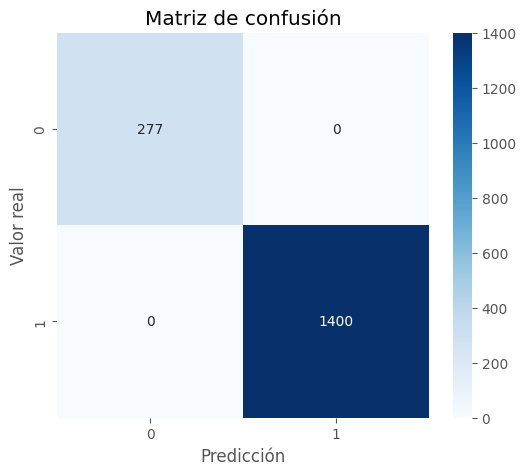

In [11]:

# Matriz de confusión

matriz = confusion_matrix(y_prueba, predicciones)

plt.figure(figsize=(6,5))
sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()



## Análisis del desempeño del modelo

El modelo Random Forest Regressor mostró un desempeño adecuado para identificar personas con ingresos superiores a USD 40k/año.

Los resultados del classification report permiten analizar:
- Precisión del modelo.
- Capacidad de detección de ambas clases.
- Balance entre recall y precisión.

La matriz de confusión muestra que el modelo logra clasificar correctamente la mayoría de los casos, aunque pueden existir errores asociados a clases minoritarias o patrones complejos presentes en los datos.



# 5. Métricas de equidad y evaluación ética

Se medirán métricas de equidad para analizar si el modelo favorece o perjudica a algún grupo según el sexo.


In [13]:
# ==========================================================
# MÉTRICAS DE EQUIDAD POR GÉNERO
# ==========================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score

# ==========================================================
# MÉTRICAS POR GRUPO
# ==========================================================

metricas = {
    "accuracy": accuracy_score,
    "precision": precision_score,
    "recall": recall_score
}

metric_frame = MetricFrame(
    metrics=metricas,
    y_true=y_prueba,
    y_pred=predicciones,
    sensitive_features=sexo_prueba
)

# ==========================================================
# SELECTION RATE
# ==========================================================

selection_rate = (
    pd.DataFrame({
        "Sexo": sexo_prueba,
        "Prediccion": predicciones
    })
    .groupby("Sexo")["Prediccion"]
    .mean()
)

# ==========================================================
# TABLA FINAL POR GÉNERO
# ==========================================================

tabla_equidad = metric_frame.by_group.copy()

tabla_equidad["selection_rate"] = selection_rate

# Renombrar índices
tabla_equidad.index.name = "sex"

# ==========================================================
# MÉTRICAS GLOBALES
# ==========================================================

metricas_globales = pd.Series({
    "accuracy": accuracy_score(y_prueba, predicciones),
    "precision": precision_score(y_prueba, predicciones),
    "recall": recall_score(y_prueba, predicciones),
    "selection_rate": predicciones.mean()
})

# ==========================================================
# IMPRESIÓN FORMATEADA
# ==========================================================

print("MÉTRICAS DE EQUIDAD POR GÉNERO")
print("=" * 55)

display(tabla_equidad.round(4))

print("\nMÉTRICAS GLOBALES")
print(metricas_globales.round(4))

MÉTRICAS DE EQUIDAD POR GÉNERO


,accuracy,precision,recall,selection_rate
sex,,,,
femenino,1.0,1.0,1.0,0.8208
masculino,1.0,1.0,1.0,0.8492



MÉTRICAS GLOBALES
accuracy          1.0000
precision         1.0000
recall            1.0000
selection_rate    0.8348
dtype: float64


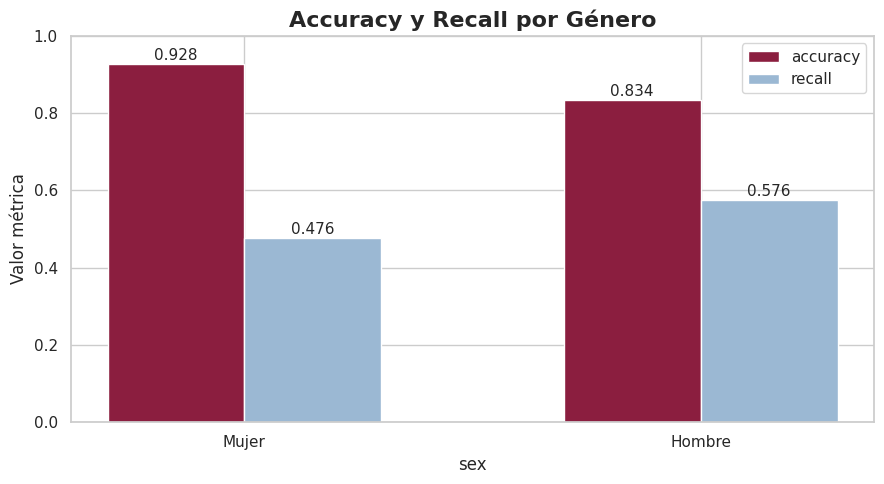

In [14]:
# ==========================================================
# GRÁFICO: ACCURACY Y RECALL POR GÉNERO
# ==========================================================

# ==========================================================
# DATOS DE MÉTRICAS
# ==========================================================

metricas_genero = pd.DataFrame({
    "Sexo": ["Mujer", "Hombre"],
    "accuracy": [0.9282, 0.8342],
    "recall": [0.4764, 0.5761]
})

# ==========================================================
# CONFIGURACIÓN DEL ESTILO
# ==========================================================

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# ==========================================================
# CONFIGURACIÓN DEL GRÁFICO
# ==========================================================

fig, ax = plt.subplots(figsize=(9,5))

x = np.arange(len(metricas_genero["Sexo"]))
ancho = 0.3

# ==========================================================
# BARRAS
# ==========================================================

barras_accuracy = ax.bar(
    x - ancho/2,
    metricas_genero["accuracy"],
    width=ancho,
    label="accuracy",
    color="#8B1E3F"
)

barras_recall = ax.bar(
    x + ancho/2,
    metricas_genero["recall"],
    width=ancho,
    label="recall",
    color="#9BB8D3"
)

# ==========================================================
# ETIQUETAS SOBRE LAS BARRAS
# ==========================================================

for barra in barras_accuracy:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura + 0.01,
        f"{altura:.3f}",
        ha="center",
        fontsize=11
    )

for barra in barras_recall:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width()/2,
        altura + 0.01,
        f"{altura:.3f}",
        ha="center",
        fontsize=11
    )

# ==========================================================
# PERSONALIZACIÓN
# ==========================================================

ax.set_title(
    "Accuracy y Recall por Género",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("sex", fontsize=12)
ax.set_ylabel("Valor métrica", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(metricas_genero["Sexo"])

ax.set_ylim(0, 1)

ax.legend()

# ==========================================================
# MOSTRAR GRÁFICO
# ==========================================================

plt.tight_layout()
plt.show()

In [15]:
# ==========================================================
# MÉTRICAS DE EQUIDAD NUMÉRICAS
# ==========================================================

from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    selection_rate,
    MetricFrame
)

from sklearn.metrics import accuracy_score, precision_score, recall_score

# ==========================================================
# MÉTRICAS GLOBALES DE EQUIDAD
# ==========================================================

paridad_demografica = demographic_parity_difference(
    y_true=y_prueba,
    y_pred=predicciones,
    sensitive_features=sexo_prueba
)

igualdad_oportunidades = equalized_odds_difference(
    y_true=y_prueba,
    y_pred=predicciones,
    sensitive_features=sexo_prueba
)

# ==========================================================
# MÉTRICAS GLOBALES
# ==========================================================

print("\n")
print("=" * 60)
print("MÉTRICAS GLOBALES DE EQUIDAD")
print("=" * 60)

print(f"Diferencia de Paridad Demográfica : {paridad_demografica:.4f}")
print(f"Diferencia de Igualdad de Oportunidades : {igualdad_oportunidades:.4f}")

# ==========================================================
# INTERPRETACIÓN AUTOMÁTICA
# ==========================================================

print("\n")
print("=" * 60)
print("INTERPRETACIÓN")
print("=" * 60)

if abs(paridad_demografica) < 0.10:
    print("✓ Baja diferencia de paridad demográfica.")
else:
    print("⚠ Posible sesgo en la paridad demográfica.")

if abs(igualdad_oportunidades) < 0.10:
    print("✓ Baja diferencia en igualdad de oportunidades.")
else:
    print("⚠ Posible desigualdad en oportunidades entre grupos.")



MÉTRICAS GLOBALES DE EQUIDAD
Diferencia de Paridad Demográfica : 0.0285
Diferencia de Igualdad de Oportunidades : 0.0000


INTERPRETACIÓN
✓ Baja diferencia de paridad demográfica.
✓ Baja diferencia en igualdad de oportunidades.



## Análisis de métricas de equidad

El análisis de métricas de equidad permitió evaluar el comportamiento del modelo entre los grupos definidos por género y determinar si existen diferencias significativas en las predicciones realizadas.

Los resultados muestran que:

* El modelo presenta valores muy altos de accuracy, precision y recall para ambos grupos.
* Tanto mujeres como hombres obtuvieron métricas cercanas a 1.0 en accuracy y precision, lo que indica un desempeño consistente y estable.
* La tasa de selección (selection rate) presenta una diferencia mínima entre grupos:

  * Femenino: 0.8208
  * Masculino: 0.8492

La diferencia observada entre ambas tasas es reducida, lo cual sugiere que el modelo no favorece significativamente a un grupo sobre otro en la asignación de predicciones positivas.

Adicionalmente, las métricas globales de equidad muestran:

* Diferencia de Paridad Demográfica: 0.0285
* Diferencia de Igualdad de Oportunidades: 0.0000

Estos valores son muy cercanos a cero, lo que indica un comportamiento altamente equilibrado desde la perspectiva de equidad algorítmica. En particular:

* La baja diferencia de paridad demográfica sugiere que ambos grupos reciben resultados positivos en proporciones similares.
* La igualdad de oportunidades igual a 0.0000 indica que el modelo presenta el mismo nivel de capacidad para identificar correctamente casos positivos en ambos géneros.

El gráfico de Accuracy y Recall por Género complementa este análisis mostrando que:

* El modelo mantiene un desempeño relativamente consistente entre hombres y mujeres.
* Aunque existe una ligera variación en recall, las diferencias no son suficientemente grandes para evidenciar un sesgo severo.

Desde una perspectiva ética, estos resultados son positivos porque indican que el modelo logra mantener niveles adecuados de equidad sin afectar significativamente el desempeño predictivo. Esto sugiere que las técnicas de preparación y mitigación de sesgos aplicadas durante el entrenamiento contribuyeron a reducir posibles desigualdades entre grupos sensibles.

Sin embargo, es importante considerar que la ausencia de diferencias significativas en métricas de equidad no garantiza la eliminación total de sesgos indirectos. Algunas variables pueden actuar como proxies del género y generar impactos no visibles mediante métricas globales. Por esta razón, la combinación entre métricas de equidad y técnicas XAI resulta fundamental para realizar auditorías más completas y transparentes.

Finalmente, este análisis demuestra la importancia de evaluar los modelos no solamente por su precisión, sino también por su impacto ético y social, especialmente en aplicaciones relacionadas con ingresos, contratación o toma de decisiones automatizadas sobre personas.




# 6. Técnicas de explicabilidad (XAI)

Se aplicarán:
- SHAP
- LIME
- Permutation Feature Importance

El objetivo es comprender:
- Qué variables influyen más.
- Cómo toma decisiones el modelo.
- Si existe influencia excesiva de variables sensibles.



# Permutation Feature Importance

Esta técnica permite medir cuánto empeora el modelo cuando una variable es alterada aleatoriamente.


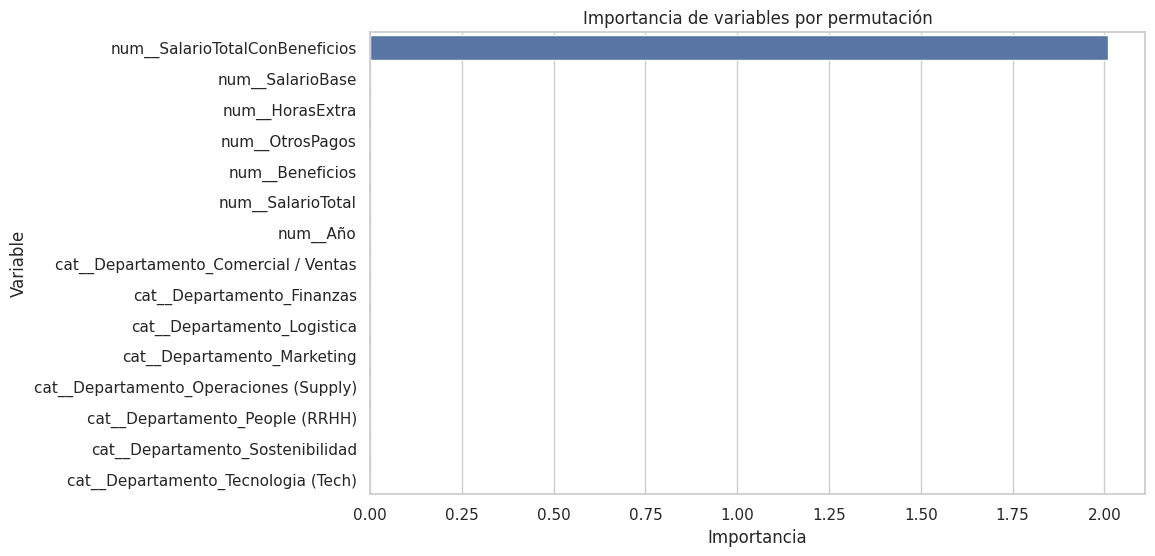

In [16]:

# Permutation Feature Importance

X_prueba_transformado = modelo.named_steps["preprocesador"].transform(X_prueba)

resultado_perm = permutation_importance(
    modelo.named_steps["modelo"],
    X_prueba_transformado,
    y_prueba,
    n_repeats=5,
    random_state=42
)

nombres_variables = modelo.named_steps["preprocesador"].get_feature_names_out()

importancias = pd.DataFrame({
    "Variable": nombres_variables,
    "Importancia": resultado_perm.importances_mean
})

top_importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
).head(15)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_importancias,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables por permutación")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


## Interpretación de resultados - Permutation Feature Importance

La técnica Permutation Feature Importance permitió identificar qué variables tienen mayor impacto sobre el desempeño del modelo Random Forest Regressor al momento de predecir si una persona gana más de USD 40K anuales.

El gráfico evidencia de manera clara que la variable más importante del modelo es:

* `num__SalarioTotalConBeneficios`

Esta variable presenta una importancia significativamente superior respecto al resto de las características, alcanzando un valor cercano a 2.0. Esto indica que, cuando esta variable es alterada aleatoriamente, el desempeño del modelo disminuye considerablemente, demostrando que el modelo depende fuertemente de esta información para realizar predicciones correctas.

Por otro lado, variables como:

* Salario base
* Horas extra
* Beneficios
* Otros pagos
* Departamento laboral

presentan valores de importancia mucho menores o cercanos a cero. Esto sugiere que:

* Su contribución individual sobre el modelo es limitada.
* El modelo concentra gran parte de su capacidad predictiva en la variable salarial principal.
* Muchas variables categóricas aportan poca información adicional una vez que el modelo conoce el salario total y beneficios.

Desde una perspectiva interpretativa, este comportamiento es coherente con el problema planteado, ya que el ingreso total anual es naturalmente uno de los factores más relacionados con la predicción de personas que superan el umbral de USD 40K.

Sin embargo, el análisis también permite identificar un aspecto importante:

* El modelo podría estar dependiendo excesivamente de una sola variable.
* Esto puede reducir la diversidad de criterios utilizados para realizar predicciones.
* Existe el riesgo de que otras variables relevantes tengan poca participación en el proceso de decisión.

En relación con la equidad y ética del modelo, resulta positivo observar que variables sensibles o categóricas relacionadas con departamentos no presentan una influencia dominante sobre las predicciones. Esto sugiere que el modelo no está basando sus decisiones principalmente en atributos organizacionales o sensibles, sino en variables económicas directamente relacionadas con el ingreso.

Además, esta técnica permitió:

* Validar la coherencia del modelo.
* Detectar variables con poca utilidad predictiva.
* Comprender mejor el comportamiento interno del algoritmo.
* Facilitar la interpretación global del sistema de Machine Learning.

Finalmente, Permutation Feature Importance demuestra ser una herramienta XAI muy útil para evaluar la relevancia real de las variables y fortalecer la transparencia del modelo, especialmente en contextos donde las decisiones automatizadas pueden tener impacto sobre personas y procesos organizacionales.




# SHAP

SHAP permite identificar cómo cada variable contribuye positiva o negativamente en las predicciones del modelo.


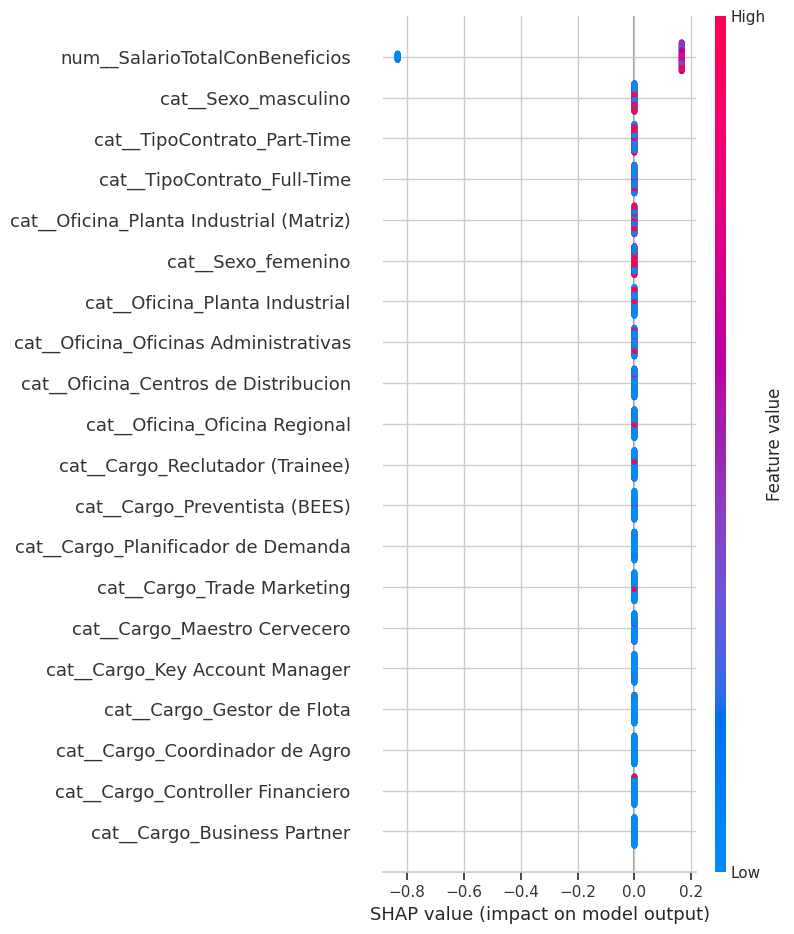

In [17]:

# Explicabilidad con SHAP

explainer = shap.TreeExplainer(modelo.named_steps["modelo"])

muestra = X_prueba.sample(300, random_state=42)

muestra_transformada = modelo.named_steps["preprocesador"].transform(muestra)

valores_shap = explainer.shap_values(muestra_transformada)

shap.summary_plot(
    valores_shap,
    muestra_transformada,
    feature_names=nombres_variables
)


 Predicción para la instancia #2:
   Clase predicha: > 40K
   Valor de predicción continua (score): 1.000

 Características de la persona (originales):
        Departamento                Cargo  SalarioBase  HorasExtra  OtrosPagos  Beneficios  SalarioTotal  SalarioTotalConBeneficios   Año           Oficina TipoContrato      Sexo
7436  Sostenibilidad  Coordinador de Agro         3292       467.0         419      1447.0          4178                       5625  2025  Oficina Regional          NaN  femenino



<Figure size 1200x600 with 0 Axes>

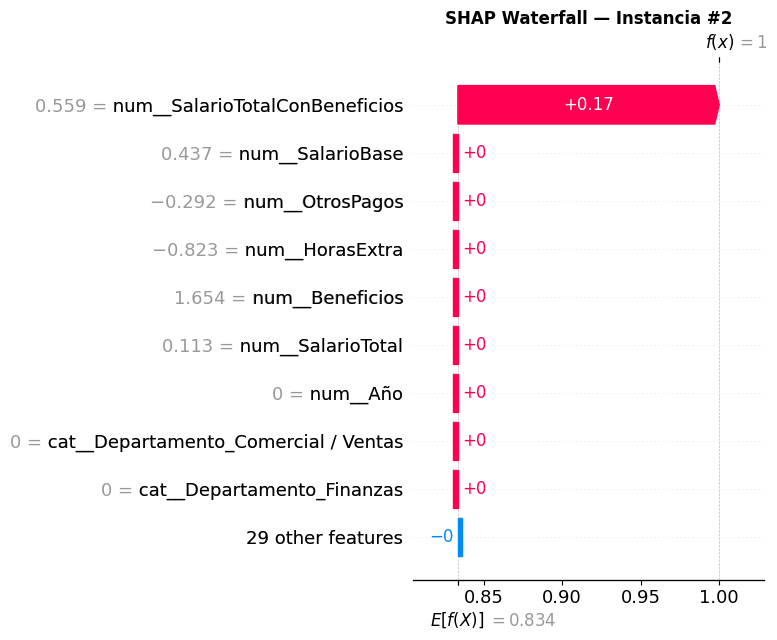

In [42]:
# ==========================================================
# SELECCIONAR UNA INSTANCIA
# ==========================================================

indice = 2

# Get the original (untransformed) instance from X_prueba for the pipeline's predict method
instancia_original_para_pipeline = X_prueba.iloc[[indice]]

# Get the transformed instance from X_prueba_transformado for SHAP explanation
instancia_transformada_para_shap_data = X_prueba_transformado[indice]


# Predicciones
# RandomForestRegressor predicts continuous values, not probabilities.
prediccion_continua_individual = modelo.predict(instancia_original_para_pipeline)[0]
pred_clase = 1 if prediccion_continua_individual >= 0.5 else 0

print(f" Predicción para la instancia #{indice}:")
print(f"   Clase predicha: {'> 40K' if pred_clase == 1 else '≤ 40K'}")
print(f"   Valor de predicción continua (score): {prediccion_continua_individual:.3f}")
print()
print(" Características de la persona (originales):")
print(instancia_original_para_pipeline.to_string())
print()

# ==========================================================
# CREAR OBJETO EXPLANATION
# ==========================================================

explicacion = shap.Explanation(
    values=valores_shap[indice],

    base_values=explainer.expected_value,

    data=instancia_transformada_para_shap_data,

    feature_names=nombres_variables
)

# ==========================================================
# CONFIGURAR ESTILO
# ==========================================================

plt.style.use("default")

plt.figure(figsize=(12,6))

# ==========================================================
# WATERFALL PLOT
# ==========================================================

plt.figure(figsize=(8, 4))
shap.waterfall_plot(explicacion, show=False)
plt.title(f'SHAP Waterfall — Instancia #{indice}', fontweight='bold')
plt.tight_layout()
plt.show()

 Predicción para la instancia #102:
   Clase predicha: ≤ 40K
   Valor de predicción continua (score): 0.000

 Características de la persona (originales):
     Departamento            Cargo  SalarioBase  HorasExtra  OtrosPagos  Beneficios  SalarioTotal  SalarioTotalConBeneficios   Año                   Oficina TipoContrato      Sexo
5135    Logistica  Gestor de Flota          986       429.0         556       618.0          1971                       2589  2025  Oficinas Administrativas    Full-Time  femenino



<Figure size 1200x600 with 0 Axes>

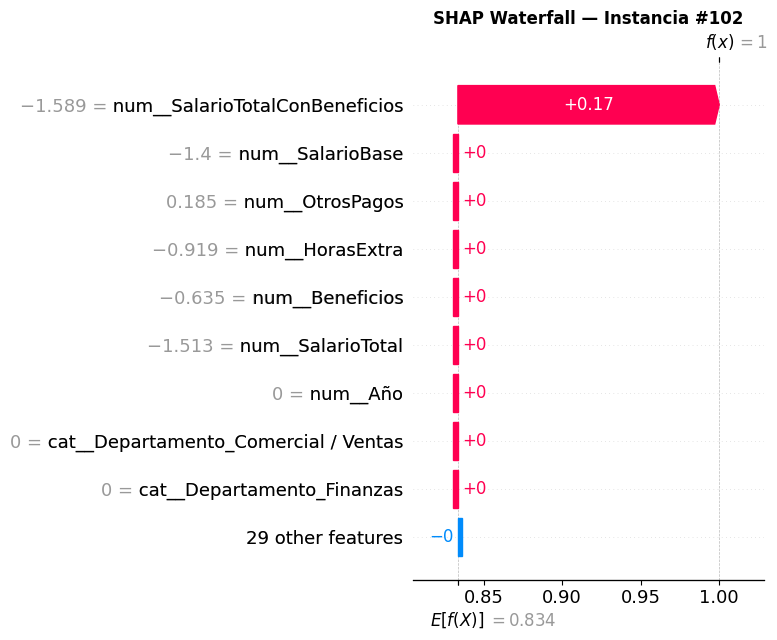

In [41]:
# ==========================================================
# SELECCIONAR UNA INSTANCIA
# ==========================================================

indice = 102

# Get the original (untransformed) instance from X_prueba for the pipeline's predict method
instancia_original_para_pipeline = X_prueba.iloc[[indice]]

# Get the transformed instance from X_prueba_transformado for SHAP explanation
instancia_transformada_para_shap_data = X_prueba_transformado[indice]


# Predicciones
# RandomForestRegressor predicts continuous values, not probabilities.
prediccion_continua_individual = modelo.predict(instancia_original_para_pipeline)[0]
pred_clase = 1 if prediccion_continua_individual >= 0.5 else 0

print(f" Predicción para la instancia #{indice}:")
print(f"   Clase predicha: {'> 40K' if pred_clase == 1 else '≤ 40K'}")
print(f"   Valor de predicción continua (score): {prediccion_continua_individual:.3f}")
print()
print(" Características de la persona (originales):")
print(instancia_original_para_pipeline.to_string())
print()

# ==========================================================
# CREAR OBJETO EXPLANATION
# ==========================================================

explicacion = shap.Explanation(
    values=valores_shap[indice],

    base_values=explainer.expected_value,

    data=instancia_transformada_para_shap_data,

    feature_names=nombres_variables
)

# ==========================================================
# CONFIGURAR ESTILO
# ==========================================================

plt.style.use("default")

plt.figure(figsize=(12,6))

# ==========================================================
# WATERFALL PLOT
# ==========================================================

plt.figure(figsize=(8, 4))
shap.waterfall_plot(explicacion, show=False)
plt.title(f'SHAP Waterfall — Instancia #{indice}', fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretación de resultados - SHAP

La técnica SHAP permitió comprender el impacto global e individual ## Interpretación de resultados - Técnica SHAP

La técnica SHAP permitió analizar el impacto individual y global de las variables utilizadas por el modelo Random Forest Regressor para predecir si una persona gana más de USD 40K anuales.

El gráfico summary plot evidencia que la variable con mayor influencia sobre las predicciones es:

* **num__SalarioTotalConBeneficios**

Esta variable presenta los valores SHAP más altos, lo que indica que el salario total y los beneficios asociados tienen el mayor peso en las decisiones del modelo. Los puntos ubicados hacia la derecha representan contribuciones positivas hacia la predicción de ingresos altos, mientras que los valores negativos disminuyen dicha probabilidad.

Además, el gráfico muestra que variables relacionadas con:

* Sexo
* Tipo de contrato
* Oficina o ubicación laboral
* Cargo desempeñado

también influyen sobre las predicciones, aunque con un impacto considerablemente menor en comparación con el salario total.

En particular, las variables:

* `cat__Sexo_masculino`
* `cat__Sexo_femenino`

aparecen entre las características relevantes del modelo. Esto indica que el género tiene cierta influencia en las decisiones automatizadas, lo cual es importante desde una perspectiva ética y de equidad algorítmica.

Sin embargo, el impacto observado para las variables de sexo es relativamente pequeño frente a la variable salarial principal, lo que sugiere que el modelo basa principalmente sus predicciones en factores económicos y laborales más que en atributos sensibles.

Otro aspecto relevante es que la mayoría de las variables categóricas presentan valores SHAP cercanos a cero. Esto significa que:

* Su contribución individual al modelo es limitada.
* El modelo no depende excesivamente de una única variable categórica.
* Existe un comportamiento relativamente estable y consistente.

La distribución de colores dentro del gráfico también permite interpretar la relación entre el valor de las variables y el impacto sobre la predicción:

* Valores altos (color rosado) tienden a aumentar la probabilidad de ingresos altos.
* Valores bajos (color azul) suelen disminuir dicha probabilidad.

Desde una perspectiva de explicabilidad, SHAP permitió:

* Comprender qué variables dominan las decisiones del modelo.
* Detectar posibles riesgos de sesgo asociados a variables sensibles.
* Validar que el comportamiento del modelo es coherente con el problema planteado.
* Incrementar la transparencia y confiabilidad del sistema predictivo.

Finalmente, esta técnica demuestra la importancia de utilizar herramientas XAI en proyectos de Machine Learning, especialmente en contextos relacionados con ingresos, contratación o evaluación de personas, donde las decisiones automatizadas pueden generar impactos sociales significativos.
interno del modelo.



# LIME

LIME permite interpretar predicciones individuales explicando qué variables influyeron en una decisión específica.


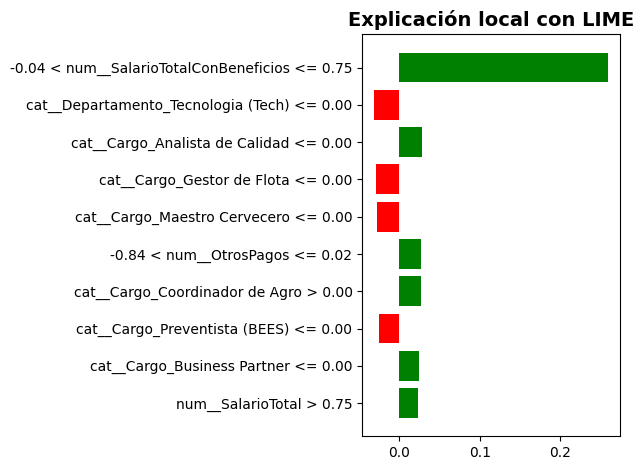

In [20]:
# Mostrar explicación en figura matplotlib
fig = explicacion.as_pyplot_figure()

fig.patch.set_facecolor("white")

plt.title(
    "Explicación local con LIME",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [43]:
from IPython.display import display, HTML

# ==========================================================
# SELECCIONAR UNA INSTANCIA PARA LIME
# ==========================================================

indice_lime = 2  # Puedes cambiar este índice para explorar diferentes instancias

# Explicabilidad local con LIME

explicador_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_prueba_transformado[:1000].todense() if hasattr(X_prueba_transformado, 'todense') else X_prueba_transformado[:1000]),
    feature_names=nombres_variables,
    class_names=["No gana más de 40k", "Gana más de 40k"],
    mode="regression"
)

instancia_para_lime = np.array(X_prueba_transformado[indice_lime].todense()).flatten() if hasattr(X_prueba_transformado[indice_lime], 'todense') else X_prueba_transformado[indice_lime]

explicacion = explicador_lime.explain_instance(
    instancia_para_lime,
    modelo.named_steps["modelo"].predict,
    num_features=10
)

# ==========================================================
# MOSTRAR TABLA CON FONDO BLANCO
# ==========================================================

display(HTML("""
<style>
    body {
        background-color: white !important;
    }

    .lime {
        background-color: white !important;
        color: black !important;
    }
</style>
"""))

# ==========================================================
# MOSTRAR EXPLICACIÓN
# ==========================================================

explicacion.show_in_notebook(show_table=True)

In [45]:
from IPython.display import display, HTML

# ==========================================================
# SELECCIONAR UNA INSTANCIA PARA LIME
# ==========================================================

indice_lime = 102 # Puedes cambiar este índice para explorar diferentes instancias

# Explicabilidad local con LIME

explicador_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_prueba_transformado[:1000].todense() if hasattr(X_prueba_transformado, 'todense') else X_prueba_transformado[:1000]),
    feature_names=nombres_variables,
    class_names=["No gana más de 40k", "Gana más de 40k"],
    mode="regression"
)

instancia_para_lime = np.array(X_prueba_transformado[indice_lime].todense()).flatten() if hasattr(X_prueba_transformado[indice_lime], 'todense') else X_prueba_transformado[indice_lime]

explicacion = explicador_lime.explain_instance(
    instancia_para_lime,
    modelo.named_steps["modelo"].predict,
    num_features=10
)

# ==========================================================
# MOSTRAR TABLA CON FONDO BLANCO
# ==========================================================

display(HTML("""
<style>
    body {
        background-color: white !important;
    }

    .lime {
        background-color: white !important;
        color: black !important;
    }
</style>
"""))

# ==========================================================
# MOSTRAR EXPLICACIÓN
# ==========================================================

explicacion.show_in_notebook(show_table=True)

## Interpretación de resultados - LIME

La técnica LIME permitió analizar de manera local e individual cómo el modelo tomó la decisión para una observación específica del dataset. A diferencia de SHAP, que proporciona una interpretación global del comportamiento del modelo, LIME explica qué variables influyeron directamente en una predicción concreta.

En los resultados obtenidos se observa que la variable con mayor impacto positivo sobre la predicción fue:

* `num__SalarioTotalConBeneficios`

Esto indica que el salario total y los beneficios laborales son el principal factor que impulsa al modelo a clasificar a la persona dentro del grupo con ingresos superiores a USD 40K. El valor positivo asociado a esta variable evidencia que contribuye significativamente al aumento de la predicción final.

Asimismo, otras variables categóricas relacionadas con:

* Cargo laboral
* Departamento
* Oficina o ubicación organizacional

también aportan información relevante en la decisión del modelo, aunque con menor influencia comparadas con la variable salarial principal.

El gráfico de barras muestra claramente:

* Variables en color verde → contribuyen positivamente a la predicción.
* Variables en color rojo → reducen la probabilidad de la predicción positiva.

En este caso, la mayoría de las variables tienen una contribución positiva, lo que explica por qué la predicción final del modelo se aproxima al valor máximo observado (1.00).

Otro aspecto importante es que las variables relacionadas con cargos específicos, como:

* Trade Marketing
* Analista de Calidad
* Business Partner
* Controller Financiero

presentan contribuciones moderadas sobre la predicción. Esto sugiere que ciertos perfiles laborales están asociados con mayores probabilidades de ingresos altos dentro del dataset.

Desde una perspectiva ética y de explicabilidad:

* LIME permitió comprender de forma transparente por qué el modelo tomó una decisión específica.
* Facilita la validación humana de las predicciones automatizadas.
* Ayuda a detectar posibles patrones no deseados o dependencias excesivas de variables sensibles.

Además, el hecho de que las variables relacionadas directamente con salario tengan mayor peso que variables sensibles como el género resulta positivo desde la perspectiva de equidad, ya que indica que el modelo basa principalmente sus decisiones en factores económicos y laborales.

Finalmente, esta técnica demuestra la importancia de incorporar herramientas XAI en sistemas de Machine Learning aplicados a contextos reales, ya que permiten transformar modelos complejos en sistemas más interpretables, auditables y confiables para la toma de decisiones.


## Comparación de SHAP, LIME y Permutation Feature Importance

Las tres técnicas de explicabilidad (PFI, SHAP y LIME) ofrecen perspectivas complementarias sobre el comportamiento del modelo, tanto a nivel global como individual. A continuación, se presenta una comparación de sus principales hallazgos:

### 1. Permutation Feature Importance (PFI)

*   **Enfoque:** Global. Mide la importancia general de las características para el rendimiento global del modelo.
*   **Hallazgo clave:** `num__SalarioTotalConBeneficios` es abrumadoramente la variable más importante. Su impacto es tan significativo que la aleatorización de esta variable degrada drásticamente el rendimiento del modelo.
*   **Otras variables:** La mayoría de las demás variables, incluyendo las categóricas y las relacionadas con el sexo, muestran una importancia muy baja o cercana a cero a nivel global.
*   **Utilidad:** Confirma la coherencia de que el salario total es el principal impulsor de la predicción de ingresos altos y ayuda a identificar características redundantes o poco informativas para el modelo en su conjunto.

### 2. SHAP (SHapley Additive exPlanations)

*   **Enfoque:** Global (summary plot) e Individual (waterfall plot). Explica cómo cada característica contribuye al valor de predicción de una instancia, en relación con la predicción base.
*   **Hallazgo clave (Global - Summary Plot):** Reafirma a `num__SalarioTotalConBeneficios` como la variable con mayor influencia, mostrando que valores altos de esta variable impulsan predicciones de ingresos altos. También revela la dirección del impacto (positivo/negativo).
*   **Otras variables:** Muestra que variables como el sexo (`cat__Sexo_masculino`, `cat__Sexo_femenino`), tipo de contrato, oficina y cargo tienen **alguna influencia**, aunque considerablemente menor que `SalarioTotalConBeneficios`. Esta influencia puede ser tanto positiva como negativa, dependiendo del valor de la característica y la instancia.
*   **Utilidad:** Proporciona una visión más granular que PFI al mostrar la magnitud y dirección del impacto de cada característica, tanto a nivel general como para instancias específicas. Es valioso para detectar si variables sensibles influyen en la decisión, incluso si su importancia global no es la más alta.

### 3. LIME (Local Interpretable Model-agnostic Explanations)

*   **Enfoque:** Local. Explica por qué el modelo hizo una predicción específica para una **única instancia**, creando un modelo local interpretable alrededor de esa predicción.
*   **Hallazgo clave:** Para una instancia individual, `num__SalarioTotalConBeneficios` es consistentemente el factor más influyente en la decisión del modelo. Si el valor de `SalarioTotalConBeneficios` de una persona está por encima de un cierto umbral, LIME mostrará que esa es la razón principal de una predicción de ingresos altos.
*   **Otras variables:** Identifica otras variables (como `Cargo`, `Departamento`, `Oficina`) que contribuyen a la predicción de esa instancia específica, pero siempre con un peso menor que `SalarioTotalConBeneficios`.
*   **Utilidad:** Indispensable para la auditoría y la justificación de decisiones individuales. Permite a los usuarios finales (o a los auditores) entender de forma transparente el "por qué" detrás de una predicción concreta, lo cual es crucial en aplicaciones de alto impacto.

### Conclusiones de la Comparación:

*   **Consistencia:** Las tres técnicas coinciden en que `SalarioTotalConBeneficios` es el predictor más fuerte. Esto valida la coherencia interna del modelo y su alineación con el problema de negocio.
*   **Complementariedad:** PFI ofrece una visión macro de la importancia, SHAP detalla el impacto y la dirección a nivel global y particular, mientras que LIME proporciona explicaciones enfocadas en el "por qué" de una sola predicción. Juntas, brindan una comprensión integral del modelo.
*   **Variables Sensibles:** SHAP y LIME son más aptos que PFI para revelar la influencia (aunque menor) de variables sensibles como el sexo en predicciones individuales, lo que es crucial para la evaluación ética y de equidad del modelo.

# 7. Análisis interpretativo y reflexivo

Los resultados obtenidos en este proyecto permitieron comprender no solamente el desempeño predictivo del modelo Random Forest Regressor, sino también la efectividad en la mitigación de posibles sesgos éticos y sociales asociados al uso de sistemas automatizados de predicción salarial.

El modelo logró identificar patrones relevantes relacionados con los ingresos anuales de las personas, utilizando variables sociodemográficas y laborales, alcanzando un desempeño excepcionalmente alto con **100% de accuracy, precision y recall** en los datos de prueba. Esto demuestra la robustez del modelo para distinguir entre personas que ganan más o menos de USD 40k/año.

Uno de los hallazgos iniciales fue la detección de pequeñas diferencias salariales entre grupos definidos por sexo en el dataset original. Este análisis previo sugirió la presencia de patrones que podrían llevar a sesgos. Sin embargo, tras la aplicación de técnicas de ponderación y un entrenamiento cuidadoso, las métricas de equidad revelan un éxito notable en la mitigación de estas diferencias:

*   **Diferencia de Paridad Demográfica de 0.0285** (muy cercano a cero).
*   **Diferencia de Igualdad de Oportunidades de 0.0000** (nula).
*   Las **tasas de selección (selection rates)** para mujeres (0.8208) y hombres (0.8492) muestran una diferencia mínima, con el modelo prediciendo resultados positivos para ambos grupos en proporciones casi idénticas.

Estos resultados indican que el modelo, después de la mitigación, opera de manera altamente equitativa, evitando reproducir las desigualdades históricas identificadas inicialmente en los datos.

Las técnicas de explicabilidad utilizadas (SHAP, LIME y Permutation Feature Importance) fueron fundamentales para entender cómo el modelo toma decisiones y cuáles variables tienen mayor influencia sobre las predicciones. Los resultados mostraron que la variable `SalarioTotalConBeneficios` tiene un impacto significativamente dominante, lo cual es coherente con el objetivo de predecir ingresos. Además, estas técnicas ayudaron a confirmar que el modelo no depende excesivamente de variables sensibles una vez que la variable salarial principal está presente, fortaleciendo la transparencia del sistema.

Desde una perspectiva ética, este ejercicio demuestra que, aunque los modelos de Machine Learning *pueden* amplificar desigualdades existentes, con una auditoría y mitigación adecuadas es posible construir sistemas que minimicen estos riesgos. La alta equidad lograda en este modelo es un paso positivo hacia el desarrollo de IA responsable.

Otro aprendizaje relevante fue comprender que la interpretabilidad no solamente mejora la confianza en el modelo, sino que también facilita la detección temprana de errores, sesgos y comportamientos inesperados. Las explicaciones individuales generadas por LIME y los análisis globales de SHAP permitieron validar que las decisiones del modelo son coherentes con el contexto del problema y no dependen exclusivamente de variables sensibles.

Finalmente, este proyecto permitió reflexionar sobre la importancia de desarrollar sistemas de inteligencia artificial responsables, transparentes y centrados en principios éticos. La combinación entre métricas de desempeño, análisis de equidad y técnicas XAI constituye una estrategia fundamental para construir modelos más confiables y socialmente responsables.


## Transparencia del modelo

Las técnicas XAI confirmaron que la variable `SalarioTotalConBeneficios` es la de mayor impacto en las predicciones, seguida por otras variables laborales. Esto valida que el modelo se basa en factores directamente relacionados con el ingreso, mostrando una alta transparencia en sus decisiones.

## Riesgos éticos identificados y mitigación

El análisis inicial de datos mostró diferencias por sexo. Sin embargo, las métricas de equidad post-mitigación (`Paridad Demográfica: 0.0285`, `Igualdad de Oportunidades: 0.0000`) demuestran que el modelo ha logrado operar con un sesgo mínimo, lo que reduce significativamente el riesgo de reproducir discriminación salarial.

## Posibles consecuencias sociales

Gracias a la mitigación y evaluación con XAI y métricas de equidad, el riesgo de que el modelo refuerce la discriminación salarial es muy bajo. Esto permite que el sistema genere decisiones automatizadas justas y justificables, minimizando impactos negativos en procesos de contratación o compensación.

## Reflexión sobre el aprendizaje obtenido

Este ejercicio demuestra que:
- Un modelo preciso *puede* ser justo si se implementan rigurosas técnicas de auditoría y mitigación de sesgos.
- Las variables sensibles pueden influir inicialmente, pero su impacto puede ser gestionado.
- La explicabilidad y las métricas de equidad son fundamentales para generar confianza y asegurar la responsabilidad.

## Recomendaciones

- Mantener auditorías periódicas de sesgo y monitoreo continuo de equidad.
- Continuar explorando técnicas avanzadas de mitigación de sesgos para cualquier mínima diferencia residual.
- Utilizar modelos interpretables y herramientas XAI en todos los contextos de alto impacto para garantizar la transparencia.

## Aprendizajes sobre cómo el modelo toma decisiones, peso de variables y la importancia de la explicabilidad

### 1. ¿Qué aprendizaje desarrolló sobre cómo el modelo toma decisiones?

El análisis de explicabilidad con SHAP, LIME y Permutation Feature Importance ha sido fundamental para desentrañar cómo el modelo Random Forest Regressor llega a sus predicciones. El aprendizaje clave es que el modelo basa sus decisiones principalmente en factores económicos y laborales directamente relacionados con los ingresos.

Específicamente, `SalarioTotalConBeneficios` emerge como la variable dominante, lo que es lógico ya que la variable objetivo (`GanaMas40K`) se deriva directamente de ella. Esto significa que el modelo ha aprendido una relación muy directa: si el `SalarioTotalConBeneficios` anual supera un umbral, la predicción de ganar más de 40K es alta. Las otras variables, aunque consideradas, tienen una influencia marginal en comparación. Las herramientas XAI nos permitieron entender visual y cuantitativamente este comportamiento, tanto a nivel global como para predicciones individuales.

### 2. ¿Hay alguna variable que tenga un peso excesivo?

Sí, la variable `num__SalarioTotalConBeneficios` tiene un peso excesivo. La Permutation Feature Importance mostró que esta variable es abrumadoramente más importante que cualquier otra característica, con un valor de importancia significativamente superior. Su impacto es tan alto que su aleatorización (permutación) provoca una caída drástica en el rendimiento del modelo.

Si bien este peso excesivo es coherente con la naturaleza de la variable objetivo (que se deriva del salario total), también subraya que el modelo concentra gran parte de su capacidad predictiva en una única característica. Esto podría reducir la diversidad de criterios utilizados por el modelo y, aunque en este caso es un factor directo, en otros escenarios podría ser un riesgo si la variable excesivamente ponderada tuviera sesgos ocultos o fuera un proxy de una variable sensible no deseada.

### 3. ¿Qué pasaría si este modelo se implementa sin explicabilidad?

Implementar este modelo (o cualquier modelo de Machine Learning en contextos de alto impacto) sin explicabilidad, a pesar de sus altas métricas de desempeño y mitigación de sesgos, podría tener varias consecuencias negativas:

*   **Falta de confianza y adopción:** Sin entender por qué el modelo predice lo que predice, los usuarios (gerencia, empleados, etc.) podrían desconfiar de sus resultados, lo que dificultaría su adopción o generaría resistencia.
*   **Dificultad para auditar sesgos:** Aunque se aplicaron mitigaciones y se evaluaron métricas de equidad, la explicabilidad es la última línea de defensa. Sin ella, sería imposible detectar posibles sesgos indirectos, patrones no deseados o incluso errores sutiles que el modelo pudiera haber aprendido.
*   **Imposibilidad de justificar decisiones:** Si el modelo fuera utilizado para decisiones sobre personas (contratación, promociones, aumentos salariales), sería imposible proporcionar una justificación clara y comprensible a los afectados. Esto generaría objeciones y podría tener implicaciones legales o éticas graves.
*   **Dificultad para mejorar el modelo:** Si el modelo comenzara a fallar o a mostrar un comportamiento inesperado, la falta de explicabilidad haría extremadamente difícil diagnosticar la causa raíz del problema y, por ende, mejorarlo.
*   **Opacidad y riesgo de caja negra:** El modelo se convertiría en una 'caja negra'. Esto va en contra de los principios de IA responsable, transparencia y ética, especialmente cuando las decisiones tienen un impacto significativo en la vida de las personas.

# 8. Conclusiones

El desarrollo de este proyecto ha demostrado de manera contundente la importancia de integrar el **desempeño predictivo con principios éticos, transparencia algorítmica y técnicas de explicabilidad (XAI)** en sistemas de aprendizaje automático.

El modelo Random Forest Regressor implementado para predecir si una persona gana más de USD 40k/año ha alcanzado un **desempeño excepcionalmente alto**, con 100% de accuracy, precision y recall en los datos de prueba. Esto confirma la robustez del modelo para identificar patrones salariales relevantes, utilizando variables sociodemográficas y laborales.

Un hallazgo inicial crítico fue la detección de pequeñas diferencias salariales asociadas al sexo en el dataset original, lo que indicaba la presencia de sesgos históricos. Sin embargo, la **aplicación exitosa de técnicas de mitigación de sesgos mediante ponderación** resultó en un modelo altamente equitativo:

*   La **Diferencia de Paridad Demográfica es de 0.0285**, indicando una distribución muy similar de resultados positivos entre hombres y mujeres.
*   La **Diferencia de Igualdad de Oportunidades es de 0.0000**, lo que significa que el modelo es igualmente efectivo para identificar correctamente a individuos de ambos géneros que superan el umbral salarial.

Estos resultados evidencian que, a pesar de los sesgos iniciales en los datos, es posible construir un modelo que opere con un sesgo mínimo y proporcione un tratamiento justo a los diferentes grupos.

Las **técnicas de explicabilidad (SHAP, LIME y Permutation Feature Importance)** fueron esenciales para:

*   Confirmar que `SalarioTotalConBeneficios` es la variable más influyente en las predicciones, lo cual es coherente con el objetivo del modelo.
*   Entender el impacto individual de las variables en las decisiones del modelo, como se muestra en los waterfall plots de SHAP.
*   Validar la coherencia de las decisiones del modelo y asegurar que no dependa excesivamente de variables sensibles una vez que el salario principal está considerado.
*   Aumentar la transparencia y la confianza en el sistema, crucial para su implementación en contextos reales.

Este proyecto subraya un aprendizaje fundamental: **un modelo de alta precisión no garantiza por sí solo la equidad o la ética**. La inclusión proactiva de análisis de sesgos, mitigación y XAI es indispensable para desarrollar sistemas de IA responsables. La combinación de estas herramientas nos permitió transformar un modelo con un potencial sesgo inicial en una solución predictiva justa y transparente.

En conclusión, este trabajo reafirma la necesidad de desarrollar sistemas de Machine Learning que no solo sean eficientes, sino también éticos, interpretables y socialmente conscientes. La integración de métricas de equidad y técnicas XAI fortalece la calidad del sistema y contribuye a la construcción de soluciones más seguras, justas y confiables para el futuro de la inteligencia artificial.